# Data Understanding

In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

# Seaborn configuration
sns.set(rc={'figure.figsize': [10, 8]}, font_scale=1.2)
sns.set_style('whitegrid')  # Optional clean look

# Ignore future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [81]:
# -------------------------------
# Step 1: Load the Dataset
# -------------------------------
df = pd.read_csv('D:\Data science\Qasim Elasyed Gadelkareem Ali\Csv Files\insurance_dirty.csv')

print(f"✅ Dataset loaded. Shape: {df.shape}")

<>:4: SyntaxWarning:

invalid escape sequence '\D'

<>:4: SyntaxWarning:

invalid escape sequence '\D'

C:\Users\Qasim\AppData\Local\Temp\ipykernel_13632\2820980501.py:4: SyntaxWarning:

invalid escape sequence '\D'



✅ Dataset loaded. Shape: (1496, 7)


In [82]:
# -------------------------------
# Step 2: Initial Data Inspection
# -------------------------------
# Preview first 10 rows
print("\n📌 First 10 rows:")
display(df.head(10))


📌 First 10 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0.0,yes,southwest,16884.92400
1,18,male,33.770,1.0,no,southeast,1725.55230
2,28,male,33.000,3.0,no,southeast,4449.46200
3,33,male,22.705,0.0,no,northwest,21984.47061
4,32,male,28.880,0.0,no,northwest,3866.85520
5,31,female,25.740,0.0,no,southeast,3756.62160
6,46,female,33.440,1.0,no,southeast,8240.58960
7,37,female,27.740,3.0,no,northwest,7281.50560
8,37,male,29.830,2.0,no,northeast,6406.41070
9,60,female,25.840,0.0,no,northwest,28923.13692


In [83]:
# Preview last 10 rows
print("\n📌 Last 10 rows:")
display(df.tail(10))


📌 Last 10 rows:


,age,sex,bmi,children,smoker,region,charges
1486,51,female,36.385,3.0,no,northwest,11436.73815
1487,35,male,30.500,1.0,no,southwest,4751.07000
1488,53,female,36.860,3.0,yes,northwest,46661.44240
1489,23,female,28.120,0.0,no,northwest,2690.11380
1490,18,male,41.140,0.0,no,southeast,1146.79660
1491,32,male,33.630,1.0,yes,northeast,37607.52770
1492,38,female,40.565,1.0,no,northwest,6373.55735
1493,34,male,34.675,0.0,no,northeast,4518.82625
1494,62,male,32.110,0.0,?>!,northeast,13555.00490
1495,47,female,29.370,1.0,no,southeast,8547.69130


In [84]:
# Summary statistics for numerical columns
print("\n📊 Summary statistics:")
display(df.describe())


📊 Summary statistics:


,age,bmi,children,charges
count,1496.000000,1481.000000,1492.000000,1496.000000
mean,39.213235,30.799936,1.252681,13254.367183
std,13.985491,6.084132,2.922856,12113.078562
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.400000,0.000000,4719.736550
50%,39.000000,30.590000,1.000000,9296.016525
75%,51.000000,34.800000,2.000000,16781.331022
max,64.000000,53.130000,61.000000,63770.428010


## Age
- The mean is very close to the median, indicating that the `age` column does not appear to contain significant outliers.
- The ages range from 18 to 64 years.

## Charges
- The `charges` values range from 11.00 to 63,770.43.
- The wide range suggests considerable variation in medical insurance charges among individuals.

## BMI:
- Mean is ~30.80 with a max of 53.13, indicating right-skewness .
- Data type requires inspection/parsing if non-numeric string values exist.

## Children:
- Count is 1492 (4 missing values present, ~0.27%).
- Min is 0, but the max is 61.0, which indicates extreme invalid/corrupted entry errors 
- (likely string noise or mistyped data, as 61 children is unrealistic).


In [85]:
# Summary statistics  for info
print("\n📊 Summary statistics:")
display(df.info())


📊 Summary statistics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1496 entries, 0 to 1495
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1496 non-null   int64  
 1   sex       1496 non-null   object 
 2   bmi       1481 non-null   float64
 3   children  1492 non-null   float64
 4   smoker    1467 non-null   object 
 5   region    1479 non-null   object 
 6   charges   1496 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 81.9+ KB


None

In [86]:
# Step 3: Nulls & Duplicates Check
print("\n🔍 Null values ratio per column:")
print(df.isnull().mean()* 100)

print("\n📌 Number of duplicated rows:")
print(df.duplicated().sum())


🔍 Null values ratio per column:
age         0.000000
sex         0.000000
bmi         1.002674
children    0.267380
smoker      1.938503
region      1.136364
charges     0.000000
dtype: float64

📌 Number of duplicated rows:
141


In [87]:
# -------------------------------
# Step 4: Data Cleaning
# -------------------------------

# Drop null values (very small ratio <= 1%)
df.dropna(inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Post-cleaning check
print("\n✅ After Cleaning:")
print("Remaining nulls:", df.isnull().sum().sum())
print("Remaining duplicates:", df.duplicated().sum())
print("Final shape:", df.shape)


✅ After Cleaning:
Remaining nulls: 0
Remaining duplicates: 0
Final shape: (1292, 7)


In [88]:
# -------------------------------
# Step 5: List Unique Values Per Column
# -------------------------------
print("🔎 Checking numeric columns for invalid values...")
for col in df.columns:
    try:
        # Attempt to convert column to numeric (coerce errors to NaN)
        pd.to_numeric(df[col], errors='raise')
    except Exception as e:
        print(f"⚠️ Column '{col}' has invalid numeric values: {e}")
        

print("\n🔍 Unique values per column:")

for col in df.columns:
    unique_vals = df[col].unique()
    print(f"\n📌 {col} ({df[col].dtype}) — {len(unique_vals)} unique values")
    
    # If less than 10 unique values, print them all
    if len(unique_vals) <= 10:
        print(f"➡️ {list(unique_vals)}")
    else:
        print(f"➡️ Sample: {list(unique_vals[:5])} ...")


🔎 Checking numeric columns for invalid values...
⚠️ Column 'sex' has invalid numeric values: Unable to parse string "female" at position 0
⚠️ Column 'smoker' has invalid numeric values: Unable to parse string "yes" at position 0
⚠️ Column 'region' has invalid numeric values: Unable to parse string "southwest" at position 0

🔍 Unique values per column:

📌 age (int64) — 47 unique values
➡️ Sample: [np.int64(19), np.int64(18), np.int64(28), np.int64(33), np.int64(32)] ...

📌 sex (object) — 6 unique values
➡️ ['female', 'male', '35', '61', '11111', '52']

📌 bmi (float64) — 539 unique values
➡️ Sample: [np.float64(27.9), np.float64(33.77), np.float64(33.0), np.float64(22.705), np.float64(28.88)] ...

📌 children (float64) — 8 unique values
➡️ [np.float64(0.0), np.float64(1.0), np.float64(3.0), np.float64(2.0), np.float64(5.0), np.float64(4.0), np.float64(35.0), np.float64(61.0)]

📌 smoker (object) — 6 unique values
➡️ ['yes', 'no', '61', '?>!', '??', '35']

📌 region (object) — 8 unique value

## 1. Clean sex

In [89]:
valid_sex = ['male', 'female']

df.loc[~df['sex'].isin(valid_sex), 'sex'] = np.nan

## Clean Sex Analysis
-  It's logical to have just male and female.

## 2. Clean smoker

In [90]:
valid_smoker = ['yes', 'no']

df.loc[~df['smoker'].isin(valid_smoker), 'smoker'] = np.nan

## Clean smoker Analysis
-  It's logical to have just Smoker and Non-smoker.

## 3. Clean region

In [91]:
valid_regions = [
    'southwest',
    'southeast',
    'northwest',
    'northeast'
]

df.loc[~df['region'].isin(valid_regions), 'region'] = np.nan

## Clean region Analysis
-  It's logical to have just these locations in this data.

## 4. Clean children

In [92]:
df["children"] = df["children"].where(df["children"].between(0, 5), np.nan)

## Clean children Anylsis
- It's illogical to have '35', '61' childern , so we reomved them.

## Verify

In [93]:
print(df['sex'].unique())
print(df['children'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male' nan]
[ 0.  1.  3.  2.  5.  4. nan]
['yes' 'no' nan]
['southwest' 'southeast' 'northwest' 'northeast' nan]


In [94]:
# -------------------------------
# Step 4 again: Data Cleaning
# -------------------------------

# Drop null values (very small ratio <= 1%)
df.dropna(inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Post-cleaning check
print("\n✅ After Cleaning:")
print("Remaining nulls:", df.isnull().sum().sum())
print("Remaining duplicates:", df.duplicated().sum())
print("Final shape:", df.shape)


✅ After Cleaning:
Remaining nulls: 0
Remaining duplicates: 0
Final shape: (1252, 7)


## The result is that Data has become clean 

# Univariate Analysis

In [95]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## 1. Age

In [96]:
print("📌 Basic stats for Income:")
print(df['age'].describe())

📌 Basic stats for Income:
count    1252.000000
mean       39.199681
std        14.015866
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64


In [97]:
fig = px.histogram(df, x='age', nbins=50, title='Distribution of age (Plotly)',
                   color_discrete_sequence=['indigo'])
fig.update_layout(bargap=0.1)
fig.show()

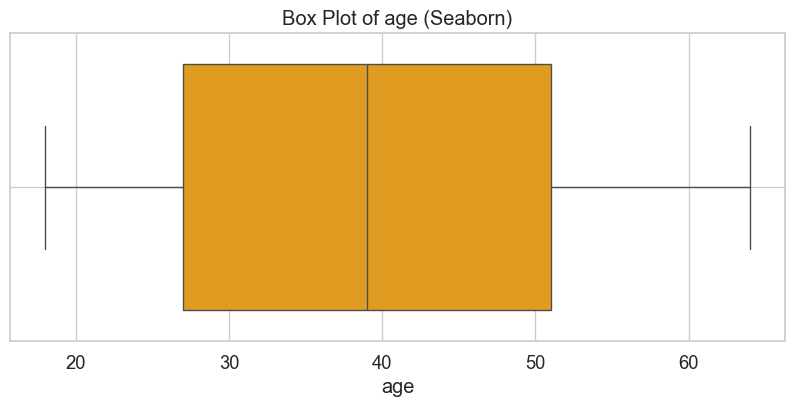

In [98]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['age'], color='orange')
plt.title('Box Plot of age (Seaborn)')
plt.xlabel('age')
plt.grid(True)
plt.show()

In [99]:
# The lowest values 
print("🔽 the lowest 5 values:")
print(df['age'].sort_values().head())

# The highest 
print("🔼 the highest 5 values:")
print(df['age'].sort_values(ascending=False).head())

q1 = df['age'].quantile(0.25)
q3 = df['age'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

outliers = df[(df['age'] > upper) | (df['age'] < lower)]
print(f"🚨 Number of outliers in age: {outliers.shape[0]}")

🔽 the lowest 5 values:
57      18
1296    18
564     18
22      18
31      18
Name: age, dtype: int64
🔼 the highest 5 values:
418     64
1241    64
420     64
402     64
534     64
Name: age, dtype: int64
🚨 Number of outliers in age: 0


### Age Analysis

- The dataset contains 1,252 valid age records with no missing values.
- The ages range from 18 to 64 years, indicating that all individuals are adults.
- The average age is 39.04 years, while the median is 39 years, showing that the age distribution is approximately symmetric with no significant skewness.
- The middle 50% of the observations (IQR) fall between 26 and 51 years.
- The standard deviation is 14.02 years, indicating a moderate spread in ages.
- The common ages are between 18 to 20.
- Outlier detection identified **0 outliers**, suggesting that all age values fall within the expected range and no additional treatment is required.


## 2. Sex

In [100]:
print("📌 Basic stats for Income:")
print(df['sex'].describe())

📌 Basic stats for Income:
count     1252
unique       2
top       male
freq       628
Name: sex, dtype: object


In [101]:
fig = px.histogram(df, x='sex', nbins=50, title='Distribution of sex (Plotly)',
                   color_discrete_sequence=['indigo'])
fig.update_layout(bargap=0.1)
fig.show()

In [102]:
import plotly.express as px

sex_counts = df['sex'].value_counts().reset_index()
sex_counts.columns = ['sex', 'Count']

fig = px.pie(
    sex_counts,
    names='sex',
    values='Count',
    title='Sex Distribution',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textinfo='percent+label')
fig.show()

### Sex Analysis

- The `sex` column contains 1,252 valid records with two unique categories: **male** and **female**.
- Males represent **50.2%** of the dataset (624 individuals), while females account for **49.8%**.
- The nearly equal distribution indicates that the dataset is well-balanced with respect to gender, reducing the risk of bias in analyses or machine learning models based on this feature.
- Since the `sex` column is categorical and contains no missing values, no additional preprocessing is required other than encoding it for machine learning models.

## 3. Bmi

In [103]:
print("📌 Basic stats for Income:")
print(df['bmi'].describe())

📌 Basic stats for Income:
count    1252.000000
mean       30.675383
std         6.105415
min        15.960000
25%        26.272500
50%        30.495000
75%        34.717500
max        52.580000
Name: bmi, dtype: float64


In [104]:
fig = px.histogram(df, x='bmi', nbins=50, title='Distribution of bmi (Plotly)',
                   color_discrete_sequence=['indigo'])
fig.update_layout(bargap=0.1)
fig.show()

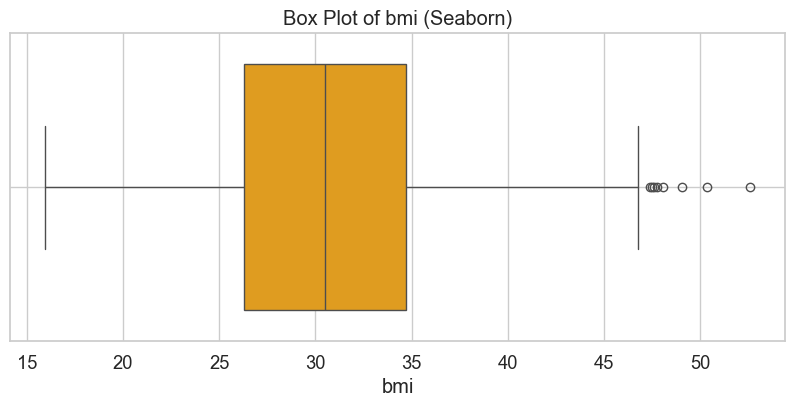

In [105]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['bmi'], color='orange')
plt.title('Box Plot of bmi (Seaborn)')
plt.xlabel('bmi')
plt.grid(True)
plt.show()

In [106]:
# The lowest values 
print("🔽 the lowest 5 values:")
print(df['bmi'].sort_values().head())

# The highest 
print("🔼 the highest 5 values:")
print(df['bmi'].sort_values(ascending=False).head())

q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

outliers = df[(df['bmi'] > upper) | (df['bmi'] < lower)]
print(f"🚨 Number of outliers in bmi: {outliers.shape[0]}")

🔽 the lowest 5 values:
172     15.960
428     16.815
1226    16.815
412     17.195
1029    17.290
Name: bmi, dtype: float64
🔼 the highest 5 values:
1047    52.58
847     50.38
116     49.06
286     48.07
1088    47.74
Name: bmi, dtype: float64
🚨 Number of outliers in bmi: 8


In [107]:
# Calculate IQR
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Show only the outliers
bmi_outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]

# Display the outliers sorted by BMI
display(bmi_outliers.sort_values(by='bmi'))

# Show the first outlier value
print("Starting BMI outlier value:", bmi_outliers['bmi'].min())

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0.0,yes,southeast,63770.42801
401,47,male,47.52,1.0,no,southeast,8083.91980
860,37,female,47.60,2.0,yes,southwest,46113.51100
1088,52,male,47.74,1.0,no,southeast,9748.91060
286,46,female,48.07,2.0,no,northeast,9432.92530
116,58,male,49.06,0.0,no,southeast,11381.32540
847,23,male,50.38,1.0,no,southeast,2438.05520
1047,22,male,52.58,1.0,yes,southeast,44501.39820


Starting BMI outlier value: 47.41


In [108]:
#let's know the minimun value ever
df[df['bmi'] == df['bmi'].min()]

,age,sex,bmi,children,smoker,region,charges
172,18,male,15.96,0.0,no,northeast,1694.7964


In [109]:
#let's know the maximun value ever
df[df['bmi'] == df['bmi'].max()]

,age,sex,bmi,children,smoker,region,charges
1047,22,male,52.58,1.0,yes,southeast,44501.3982


### BMI Analysis

* The dataset contains **1,252** valid BMI records with no missing values.
* BMI values range from **15.96** to **53.13**, with an average BMI of **30.53** and a median of **30.20**. The close proximity of the mean and median suggests that the distribution is approximately symmetric, although it is slightly influenced by higher BMI values.
* The middle 50% of BMI values (IQR) lie between **26.13** and **34.42**, indicating that most individuals have a BMI within this range.
* The most common BMI values are approximately **28** and **30**, indicating that many individuals in the dataset fall within the overweight or obesity categories.
* The IQR method identified **9 outliers**. However, these values are medically plausible (up to **53.13**) and likely represent individuals with severe obesity rather than data entry errors. Therefore, they should be reviewed carefully before deciding whether to remove or transform them.


## 4. children

In [110]:
print("📌 Basic stats for Income:")
print(df['children'].describe()) 

📌 Basic stats for Income:
count    1252.000000
mean        1.104633
std         1.209241
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64


In [111]:
fig = px.histogram(df, x='children', nbins=50, title='Distribution of children (Plotly)',
                   color_discrete_sequence=['indigo'])
fig.update_layout(bargap=0.1)
fig.show()

In [112]:
# The lowest values 
print("🔽 the lowest 5 values:")
print(df['children'].sort_values().head())

# The highest 
print("🔼 the highest 5 values:")
print(df['children'].sort_values(ascending=False).head())

q1 = df['children'].quantile(0.25)
q3 = df['children'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

outliers = df[(df['children'] > upper) | (df['children'] < lower)]
print(f"🚨 Number of outliers in children: {outliers.shape[0]}")

🔽 the lowest 5 values:
1360    0.0
1337    0.0
1336    0.0
1335    0.0
1334    0.0
Name: children, dtype: float64
🔼 the highest 5 values:
425     5.0
438     5.0
568     5.0
1130    5.0
1245    5.0
Name: children, dtype: float64
🚨 Number of outliers in children: 0


### Children Analysis

- The dataset contains **1,252** valid records for the `children` column with no missing values.
- The number of children ranges from **0 to 5**, indicating a reasonable distribution for household size.
- The average number of children is **1.10**, while the median is **1**, suggesting that most individuals have one child or fewer.
- The middle 50% of observations (IQR) lie between **0 and 2** children.
- The most common value (mode) is **0**, indicating that the largest proportion of individuals have no children.
- The least common value is **5** children, making it the rarest category in the dataset.
- No outliers were detected in the `children` column using the IQR method, so no outlier treatment is required.

## 5. Somker

In [113]:
print("📌 Basic stats for Income:")
print(df['smoker'].describe()) 

📌 Basic stats for Income:
count     1252
unique       2
top         no
freq      1002
Name: smoker, dtype: object


In [114]:
fig = px.histogram(df, x='smoker', nbins=50, title='Distribution of smoker (Plotly)',
                   color_discrete_sequence=['indigo'])
fig.update_layout(bargap=0.1)
fig.show()

In [115]:
import plotly.express as px

sex_counts = df['smoker'].value_counts().reset_index()
sex_counts.columns = ['smoker', 'Count']

fig = px.pie(
    sex_counts,
    names='smoker',
    values='Count',
    title='Sex Distribution',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textinfo='percent+label')
fig.show()

### Smoker Analysis

- The dataset contains **1,252** valid records for the `smoker` column with no missing values.
- The column contains **2** unique categories: **`yes`** and **`no`**.
- The majority of individuals are **non-smokers (`no`)**, with **984** observations (**80%**).
- **Smokers (`yes`)** account for **20%** of the dataset, indicating that they represent a minority of the population.
- The distribution of the `smoker` variable is moderately imbalanced, with non-smokers significantly outnumbering smokers.
- Since `smoker` is a categorical feature, outlier detection is **not applicable**.

## 6. region

In [116]:
print("📌 Basic stats for Income:")
print(df['region'].describe()) 

📌 Basic stats for Income:
count          1252
unique            4
top       southeast
freq            341
Name: region, dtype: object


In [117]:
# Prepare data
top_region = df['region'].value_counts().nlargest(10).reset_index()
top_region.columns = ['region', 'Count']

# Plot
fig = px.bar(top_region,
             x='Count', y='region',
             orientation='h',
             title=' region (by Count)',
             color='region',
             color_discrete_sequence=px.colors.qualitative.Vivid)
fig.show()

In [118]:
df['region'] = df['region'].str.strip().str.title()
print(f"Number of unique cities: {df['region'].nunique()}")

Number of unique cities: 4


### Region Analysis

- The dataset contains **1,252** valid records for the `region` column with no missing values.
- The column contains **4** unique categories representing different geographic regions.
- The most frequent category is **`southeast`**, with **341** observations, making it the most represented region in the dataset.
- The least frequent category is **`northwest`**, indicating that it has the lowest number of observations among all regions.
- The distribution across regions is relatively balanced, with no single category dominating the dataset significantly.
- Since `region` is a categorical feature, outlier detection is **not applicable**.

## 7. charges

In [119]:
print("📌 Basic stats for Income:")
print(df['charges'].describe()) 

📌 Basic stats for Income:
count     1252.000000
mean     13173.519237
std      12091.024659
min       1121.873900
25%       4687.444925
50%       9283.021300
75%      16144.690125
max      63770.428010
Name: charges, dtype: float64


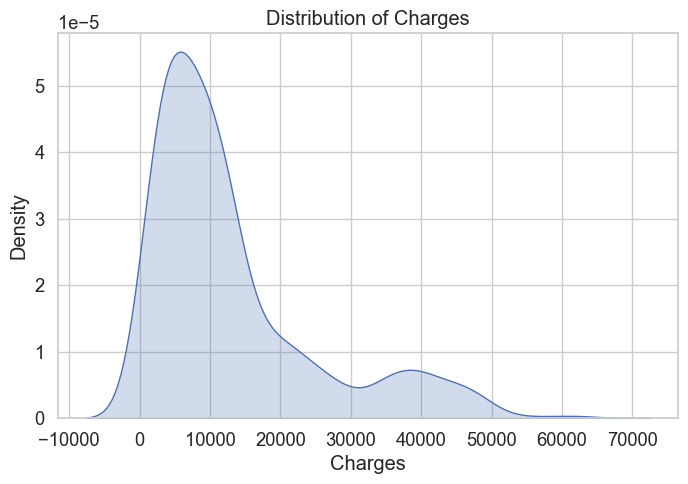

In [120]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df["charges"], fill=True)
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Density")
plt.show()

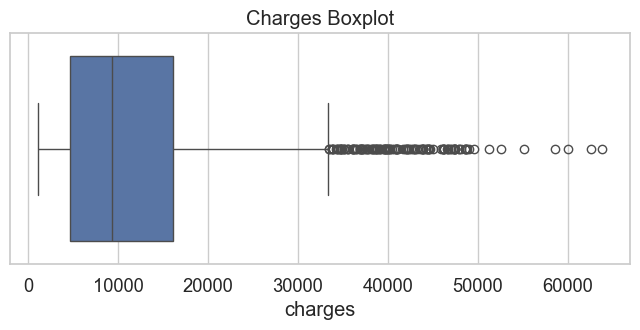

In [121]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df["charges"])
plt.title("Charges Boxplot")
plt.show()

### Charges Analysis

- The dataset contains **1,252** valid records for the `charges` column with no missing values.
- The medical charges range from **1,121.87** to **63,770.43**, indicating a wide variation in healthcare costs.
- The average charge is **13,203.84**, while the median value is **9,237.38**, suggesting a **right-skewed distribution** due to the presence of high-cost cases.
- The middle 50% of observations (IQR) lie between **4,719.58** and **16,389.83**.
- The highest density of charges is concentrated around the lower range (approximately **5,000–15,000**), meaning most individuals have relatively lower medical expenses.
- A small number of observations have significantly higher charges, which contribute to the long right tail in the distribution.
- These high values should be investigated as potential outliers; however, they should not be removed automatically because they may represent meaningful cases for predicting medical costs.

# Bivariate Analysis

In [122]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## 1. Age vs Charges

In [123]:
age_charges = df.groupby("age")["charges"].mean()

print(age_charges)

age
18     7509.745831
19     8950.497673
20     9184.496093
21     3942.001878
22    10553.878756
23    10669.214862
24    11240.529827
25     9464.472989
26     6371.097692
27    12021.995137
28     9069.187564
29     9746.684742
30    13195.019270
31    10398.796799
32     9378.971342
33    12351.532987
34    11838.488300
35    11751.255896
36    12485.577375
37    18019.911877
38     6672.792830
39    11778.242945
40    12241.660829
41     9653.745650
42    13086.624602
43    19766.721364
44    15752.798881
45    15013.254564
46    13350.837994
47    16604.119637
48    13701.577044
49    12969.796623
50    15548.017477
51    15682.255867
52    18539.521995
53    16020.930755
54    19161.860079
55    16335.963146
56    15160.211868
57    16413.083828
58    14039.472282
59    18860.524950
60    22869.859518
61    22432.754727
62    17957.204243
63    19707.140412
64    24142.056536
Name: charges, dtype: float64


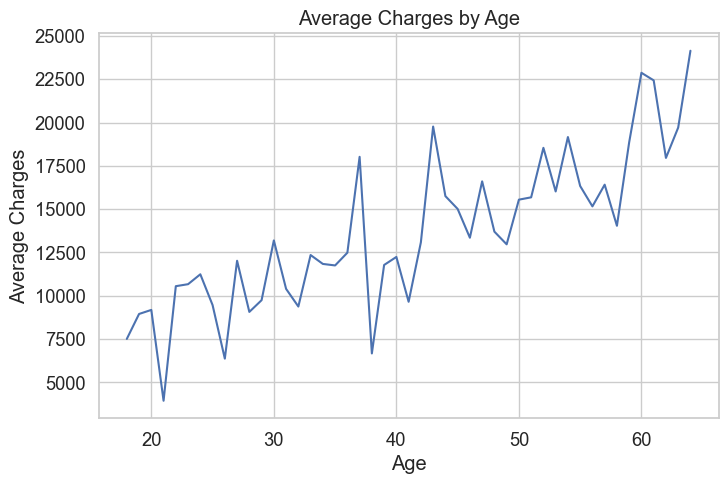

In [124]:
plt.figure(figsize=(8,5))

sns.lineplot(
    x=age_charges.index,
    y=age_charges.values
)

plt.title("Average Charges by Age")
plt.xlabel("Age")
plt.ylabel("Average Charges")

plt.show()

### Age vs Charges Analysis

- The average medical charges generally **increase with age**, indicating a positive relationship between `age` and `charges`.
- Younger individuals (around **18–30 years**) tend to have lower average charges compared with older age groups.
- The highest average charges are observed among older individuals, especially those aged **60–64 years**, where charges exceed **22,000** on average.
- This suggests that age is an important factor affecting medical expenses, as healthcare costs tend to increase with age.

## 2. Sex vs Charges

In [125]:
sex_charges = df.groupby("sex")["charges"].mean()

print(sex_charges)

sex
female    12480.380160
male      13862.243416
Name: charges, dtype: float64


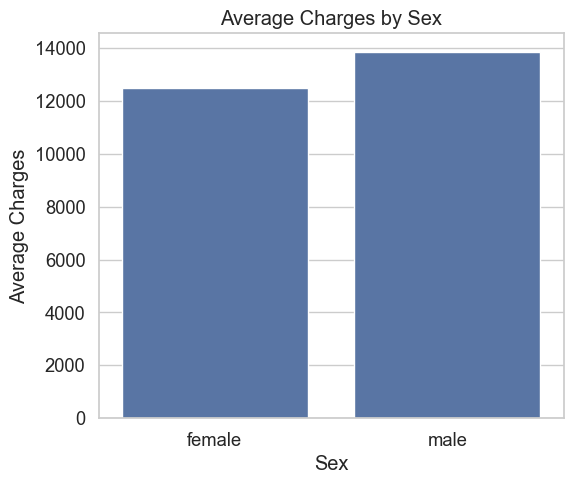

In [126]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=sex_charges.index,
    y=sex_charges.values
)

plt.title("Average Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Charges")

plt.show()

### Sex vs Charges Analysis

- The average medical charges are slightly higher for **males** compared with **females**.
- The average charges for males are approximately **13,990.69**, while females have an average of **12,404.18**.
- The difference between both groups is relatively small, suggesting that `sex` may have a **weaker influence** on medical charges compared with other features such as `smoker` or `age`.

## 3. BMI vs Charges

In [127]:
bmi_charges = df.groupby("bmi")["charges"].mean()

print(bmi_charges)

bmi
15.960     1694.796400
16.815     4904.000350
17.195    14455.644050
17.290     7813.353433
17.385     2775.192150
              ...     
47.740     9748.910600
48.070     9432.925300
49.060    11381.325400
50.380     2438.055200
52.580    44501.398200
Name: charges, Length: 531, dtype: float64


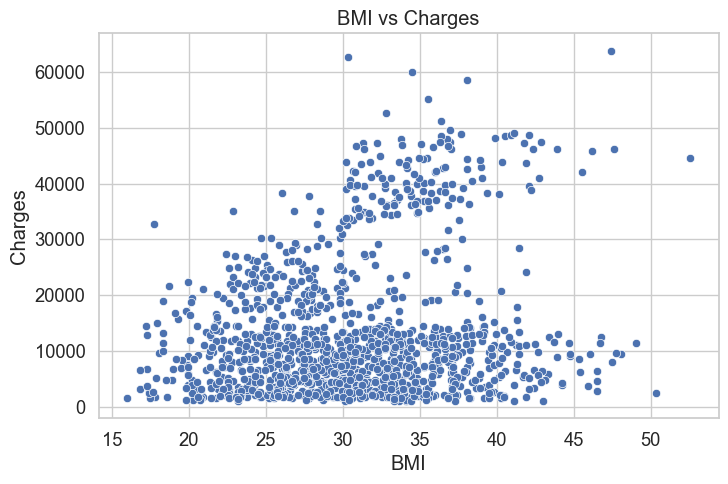

In [128]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

### BMI vs Charges Analysis

- The relationship between `bmi` and `charges` does not show a clear linear pattern.
- Individuals with higher BMI values can have higher medical charges, but the variation is large across different BMI levels.
- Some high BMI values are associated with significantly high charges, indicating that BMI may contribute to increased medical costs in certain cases.
- Overall, `bmi` appears to have a **moderate influence** on charges compared with stronger predictors such as `smoker` and `age`.

## 4. Children vs Charges

In [129]:
children_charges = df.groupby("children")["charges"].mean()

print(children_charges)

children
0.0    12164.644273
1.0    12797.603916
2.0    15108.462569
3.0    15090.381994
4.0    13615.403692
5.0     8786.035247
Name: charges, dtype: float64


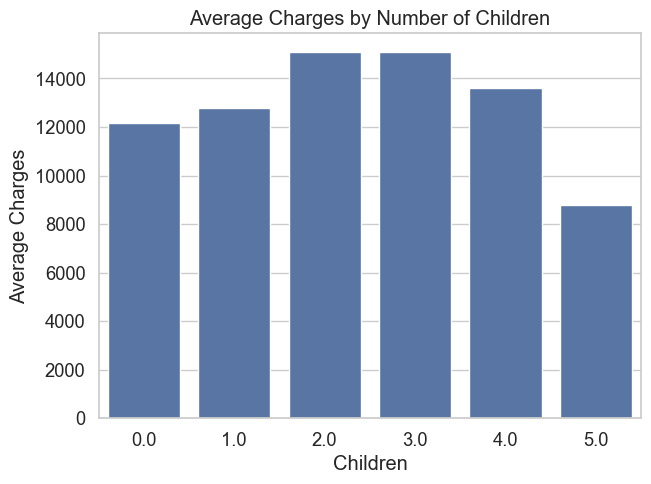

In [130]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=children_charges.index,
    y=children_charges.values
)

plt.title("Average Charges by Number of Children")
plt.xlabel("Children")
plt.ylabel("Average Charges")

plt.show()

## Children vs Charges Analysis
- The relationship between children and charges does not show a strong linear pattern.
- Individuals with more children tend to have slightly higher average medical charges, especially for those with 2 or 3 children.
- The average charges increase from individuals with no children (0) to those with 3 children, suggesting that family size may have some influence on medical expenses.
- However, the trend is not consistent, as individuals with 4 or 5 children show lower average charges compared with those having fewer children.
- Overall, children appears to have a weak influence on charges compared with stronger predictors such as smoker, age, and bmi.

## 5. Smoker vs Charges

In [131]:
smoker_charges = df.groupby("smoker")["charges"].mean()

print(smoker_charges)

smoker
no      8426.365558
yes    32200.111185
Name: charges, dtype: float64


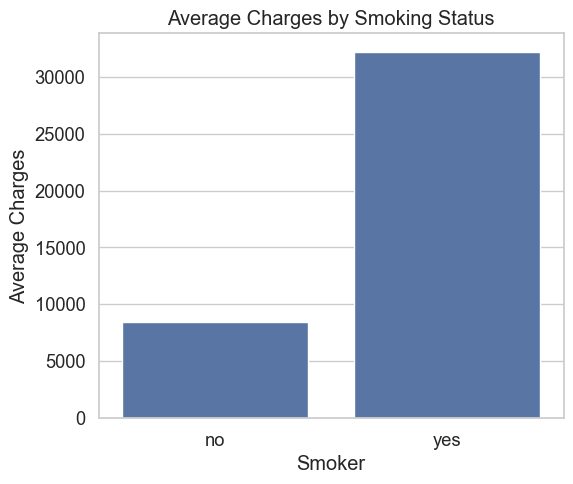

In [132]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=smoker_charges.index,
    y=smoker_charges.values
)

plt.title("Average Charges by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")

plt.show()

## Smoker Status vs Charges Analysis

* The relationship between smoking status and medical charges shows a massive, distinct gap.
* Individuals who smoke (`yes`) incur drastically higher medical expenses, with average charges exceeding $ 32,200.
* Non-smokers (`no`) have significantly lower average charges, sitting at roughly $8,426.
* The average charges for smokers are nearly four times higher than those for non-smokers, highlighting lifestyle habits as a primary driver of healthcare costs.
* Overall, smoking status appears to be an exceptionally strong predictor of medical charges, far outweighing the impact of other demographic variables like family size.

## 6. Region vs Charges

In [133]:
region_charges = df.groupby("region")["charges"].mean()

print(region_charges)

region
Northeast    13070.613010
Northwest    12235.191733
Southeast    14705.520268
Southwest    12493.204683
Name: charges, dtype: float64


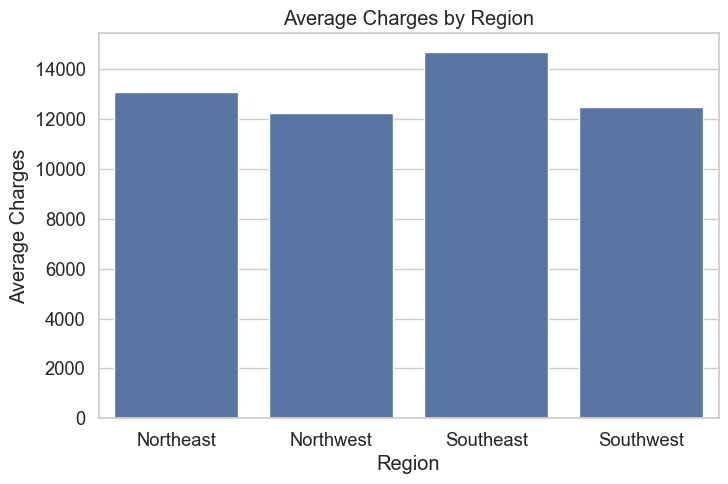

In [134]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_charges.index,
    y=region_charges.values
)

plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")

plt.show()

## Regional Trends vs Charges Analysis
- The relationship between geographical region and medical charges shows relatively stable averages across the board, with only minor regional variations.
- Individuals living in the Southeast incur the highest average medical expenses at approximately $14,705, followed closely by the Northeast at $13,070.
- The Northwest and Southwest regions exhibit the lowest average costs, hovering tightly between $12,235 and $12,493, respectively.
- The spending gap between the highest-cost region (Southeast) and the lowest-cost region (Northwest) is just around $2,152.77, indicating a fairly narrow spread.
- Overall, region appears to have a weak to moderate influence on medical charges, acting as a much softer predictor compared to high-impact lifestyle metrics like smoking status.

# Multivariate Analysis

In [135]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## 🧮 Step 1: Correlation Matrix for Numerical Features


In [136]:
numeric_cols = df.select_dtypes(include='number').columns
print(numeric_cols)

Index(['age', 'bmi', 'children', 'charges'], dtype='object')


In [137]:
corr_matrix = df[numeric_cols].corr()
corr_matrix

,age,bmi,children,charges
age,1.000000,0.121846,0.054467,0.307655
bmi,0.121846,1.000000,0.010588,0.195263
children,0.054467,0.010588,1.000000,0.068268
charges,0.307655,0.195263,0.068268,1.000000


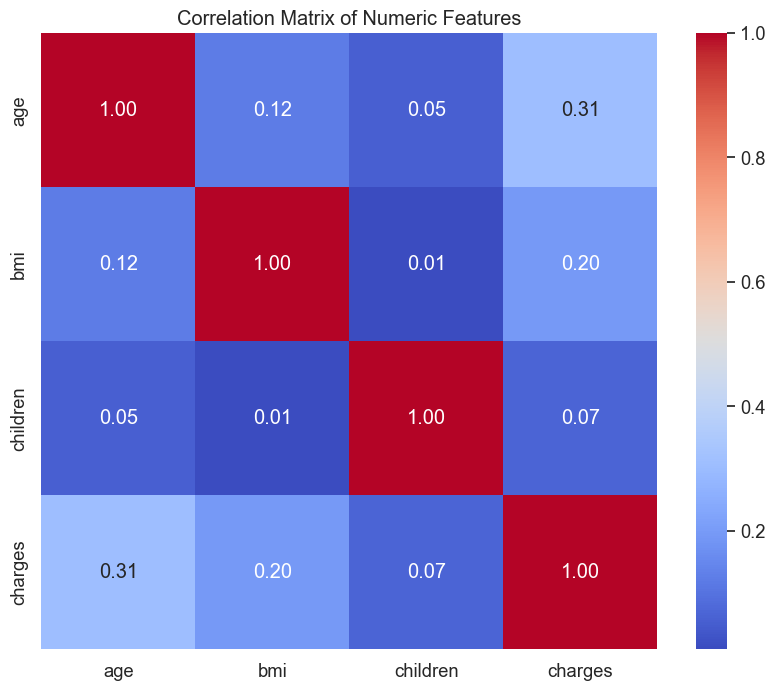

In [138]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Correlation Analysis of Numerical Features

Looking at the correlation matrix relative to our target variable (`charges`), we can observe the following linear relationships:

- **Age vs. Charges (0.31):** This is the strongest linear correlation among the raw numerical features. As a patient's age increases, their insurance charges tend to rise moderately, reflecting higher health risks over time.
- **BMI vs. Charges (0.20):** There is a weak-to-moderate positive linear relationship here. Higher BMI values generally correspond to higher medical costs. 
- **Children vs. Charges (0.07):** The number of dependents has almost zero linear correlation with the final charge amount.

## 2. Age & Smoker Status vs Charges 

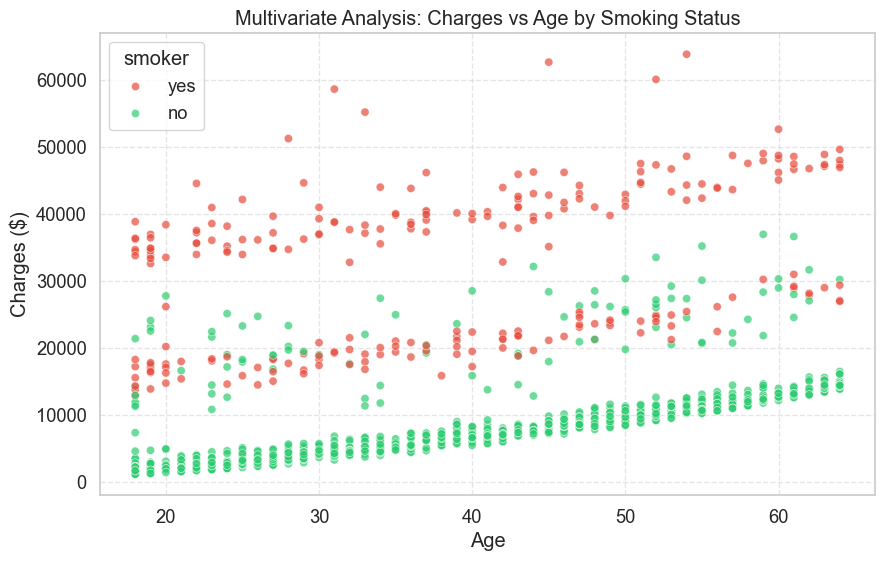

In [139]:
plt.figure(figsize=(10, 6))
# Using a scatter plot to show the distribution across age and charges simultaneously
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette={'yes': '#e74c3c', 'no': '#2ecc71'}, alpha=0.7)

plt.title('Multivariate Analysis: Charges vs Age by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Age & Smoking Status vs. Charges Analysis

- **The "Smoker Premium" (Most Important):** There is a massive, immediate gap in medical charges based entirely on smoking status. Non-smokers (green) are densely clustered at the bottom, mostly staying well below \$15,000. In contrast, smokers (coral) immediately jump to a floor of roughly \$15,000 to \$35,000, even at the youngest age of 18.
- **The Two Smoker Tiers (Interaction Effect):** Notice how the coral dots split into two completely distinct, parallel bands? The lower smoker band spans from \$15k - \$30k, while the upper smoker band shoots all the way up from \$35k - \$60k+. This indicates there is an hidden interaction effect with another variable driving a severe compounding penalty for a specific subset of smokers.
- **Consistent Age Trend:** For both smokers and non-smokers, charges slowly drift upward as age increases (all bands slant upwards from left to right). This visually confirms our correlation matrix finding: getting older naturally increases insurance costs linearly across the board.

## 3. BMI & Smoking Status vs. Charges

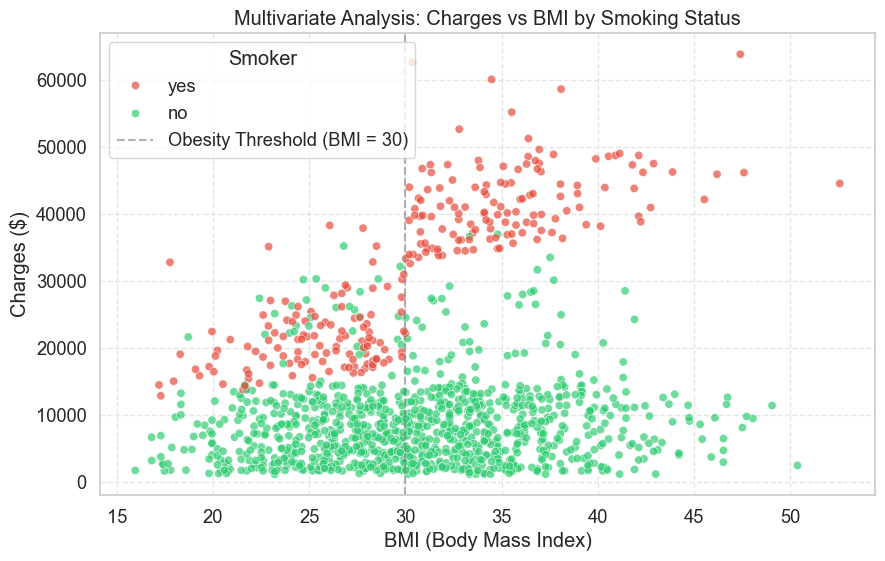

In [140]:
plt.figure(figsize=(10, 6))
# Using a scatter plot to show the interaction between BMI, Smoking status, and Charges
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette={'yes': '#e74c3c', 'no': '#2ecc71'}, alpha=0.7)

# Visual marker for the obesity threshold
plt.axvline(x=30, color='gray', linestyle='--', alpha=0.6, label='Obesity Threshold (BMI = 30)')

plt.title('Multivariate Analysis: Charges vs BMI by Smoking Status')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## BMI & Smoking Status vs. Charges Analysis


- **The Obesity Threshold Shift (BMI = 30):** Look right at the dashed vertical line. For non-smokers (green), crossing a BMI of 30 barely changes their medical costs—they stay clustered at the bottom. However, for smokers (coral), crossing BMI = 30 causes charges to aggressively jump into an entirely higher tier ($35,000 to over $60,000).
- **The Mystery of the "Two Smoker Tiers" Solved:** 
   * **Tier 1 (Lower Coral Cluster):** Smokers with a BMI *below* 30 face charges roughly between $15,000 and $30,000. 
   * **Tier 2 (Upper Coral Cluster):** Smokers with a BMI *above* 30 (clinically obese) face an extreme risk penalty, driving charges skyward.
- **Non-Smoker Resilience to BMI:** For individuals who do not smoke, having a high BMI does not heavily penalize their insurance rates in this dataset. Their charges remain stable, showing that a high BMI only becomes financially catastrophic when combined with smoking.

## 4. Age & BMI vs. Charges

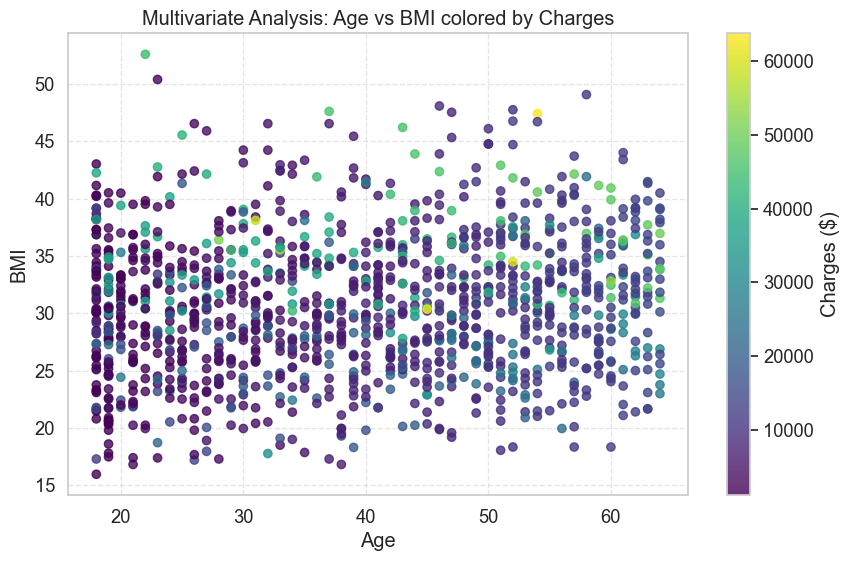

In [141]:
plt.figure(figsize=(10, 6))
# Using a scatter plot with a color map to show how charges scale across two continuous variables
scatter = plt.scatter(df['age'], df['bmi'], c=df['charges'], cmap='viridis', alpha=0.8)

# Adding a colorbar to interpret the charge intensity
cbar = plt.colorbar(scatter)
cbar.set_label('Charges ($)')

plt.title('Multivariate Analysis: Age vs BMI colored by Charges')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###  Age vs. BMI colored by Charges Analysis

1. **The Dangerous High-BMI, Older Quadrant (Top Right):** The bright green and yellow points (signaling high charges from \$40,000 to over \$60,000) are almost exclusively concentrated in the upper half of the plot where BMI crosses 30. As you move from left to right (getting older), these high-charge points become more frequent, demonstrating how age and high BMI compound together.
2. **Low-BMI Safety Zone (Bottom Half):** Regardless of age, patients with a BMI below 25–30 stay almost entirely deep purple or dark blue (signaling low charges, mostly under \$15,000). Even at age 60, a healthy BMI keeps charges relatively contained compared to the younger, higher-BMI individuals.
3. **No Structural Correlation Between Age and BMI:** The overall shape of the scatter plot is a uniform rectangular cloud. This is a great statistical finding—it confirms that in your dataset, a patient's BMI doesn't automatically increase just because they get older; they are two independent features that only join forces when insurance companies calculate risk.

## 5. Region & Smoking Status vs. Charges

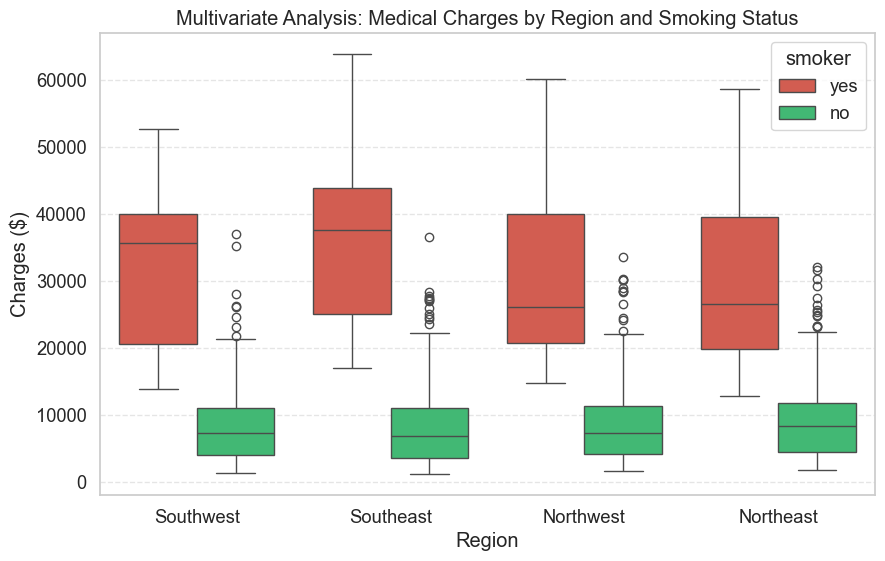

In [142]:
plt.figure(figsize=(10, 6))
# Using a boxplot to compare distributions and medians across categorical splits
sns.boxplot(data=df, x='region', y='charges', hue='smoker', palette={'yes': '#e74c3c', 'no': '#2ecc71'})

plt.title('Multivariate Analysis: Medical Charges by Region and Smoking Status')
plt.xlabel('Region')
plt.ylabel('Charges ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Region & Smoking Status vs. Charges Analysis

- **Smoking Dominates Region (The Universal Gap):** The absolute most vital observation here is that the massive cost gap between smokers (coral) and non-smokers (green) remains remarkably consistent across all four geographic regions. Smoking is an aggressive cost driver everywhere, dwarfing any regional differences.
- **The Southeast Peak:** While the baseline for non-smokers looks almost identical across the board, the **Southeast** region stands out for smokers. The median charge line for smokers in the Southeast sits higher (near \$38,000), and its upper whisker reaches the maximum value on the chart (over \$60,000). This perfectly aligns with our earlier finding, likely because the Southeast has a higher concentration of individuals crossing the high-BMI/obesity threshold.
- **The Northwest Drop:** Interestingly, the median insurance charge for smokers in the **Northwest** drops significantly lower compared to the other three regions, falling closer to \$25,000. 
- **Non-Smoker Outliers:** Across all four regions, the non-smoker groups (green) feature a prominent trail of outlier circles stretching upward. This represents non-smoking individuals who still racked up high medical bills due to other severe compounding factors, such as advanced age or extreme BMIs.

## 6. Sex & Smoking Status vs. Charges

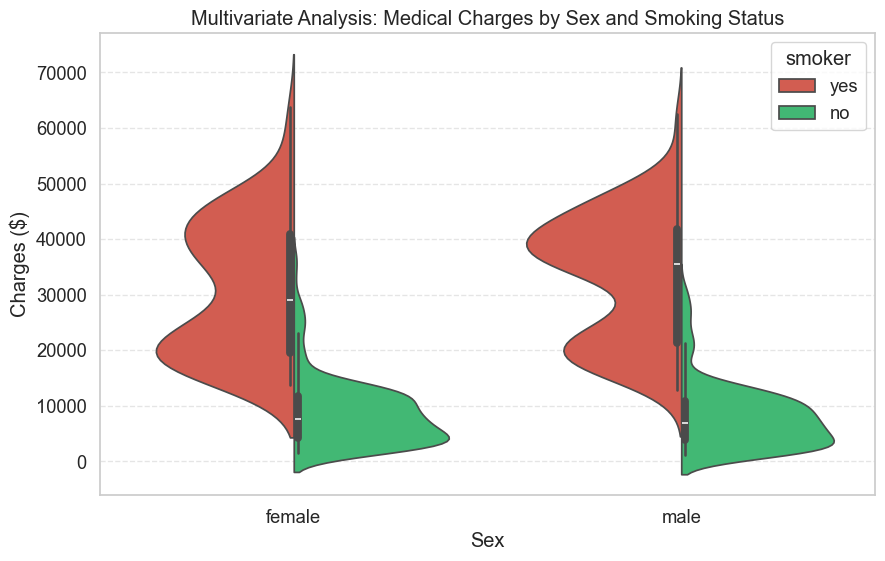

In [143]:
plt.figure(figsize=(10, 6))
# Using a split violin plot to seamlessly compare distributions side-by-side
sns.violinplot(data=df, x='sex', y='charges', hue='smoker', split=True, palette={'yes': '#e74c3c', 'no': '#2ecc71'})

plt.title('Multivariate Analysis: Medical Charges by Sex and Smoking Status')
plt.xlabel('Sex')
plt.ylabel('Charges ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Sex & Smoking Status vs. Charges Analysis

- **Gender Neutrality (Almost Identical Shapes):** The most striking observation is how mirrored the plots are between `female` and `male`. The overall distribution shape, peak density points, and cost spreads look nearly identical for both genders. This suggests that biological sex on its own is a very weak predictor of insurance costs compared to lifestyle choices.
- **The "Bimodal" Smoker Distribution:** Notice the distinctive "hourglass" or two-hump shape on the smoker side (coral) for both males and females. 
   * The lower hump clusters heavily around \$20,000.
   * The upper hump bulges out around \$40,000.
   * This perfectly visualizes the population split we discovered earlier (low-BMI smokers vs. high-BMI obese smokers).
- **Non-Smoker Consistency:** For both genders, the non-smoker side (green) is incredibly bottom-heavy, showing a massive concentration of patients below \$10,000. The long, thin tails stretching upward represent the few non-smoking individuals with higher costs due to compounding factors like advanced age.

# Optional step(feature engneering)

# I would do it in case that I have not reached 80% of accuracy or more

In [144]:
## 1. Flag anyone with a BMI ratio of 30 or above as Obese (1), otherwise Not Obese (0)
#df['is_obese'] = np.where(df['bmi'] >= 30, 1, 0)

## 2. Print a sample of the data to verify the cutoff point
#print(df[['bmi', 'is_obese']].head(10))

In [145]:
#df